<a href="https://colab.research.google.com/github/ambika-1513/Computer-vision-learning/blob/main/bev_perspective_transform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

In [2]:
torch.cuda.is_available()

True

In [5]:
torch.cuda.get_device_name(0)

'Tesla T4'

In [9]:
import cv2
import matplotlib.pyplot as plt

In [10]:
cap = cv2.VideoCapture("traffic.mp4")
ret,frame = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

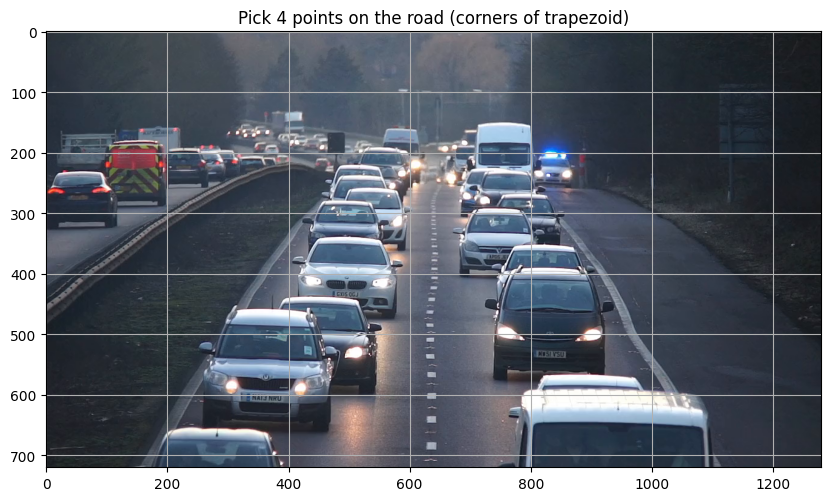

Image dimensions: (720, 1280, 3)


In [11]:
plt.figure(figsize=(10,6))
plt.imshow(frame_rgb)
plt.title("Pick 4 points on the road (corners of trapezoid)")
plt.grid(True)
plt.show()

print("Image dimensions:", frame.shape)

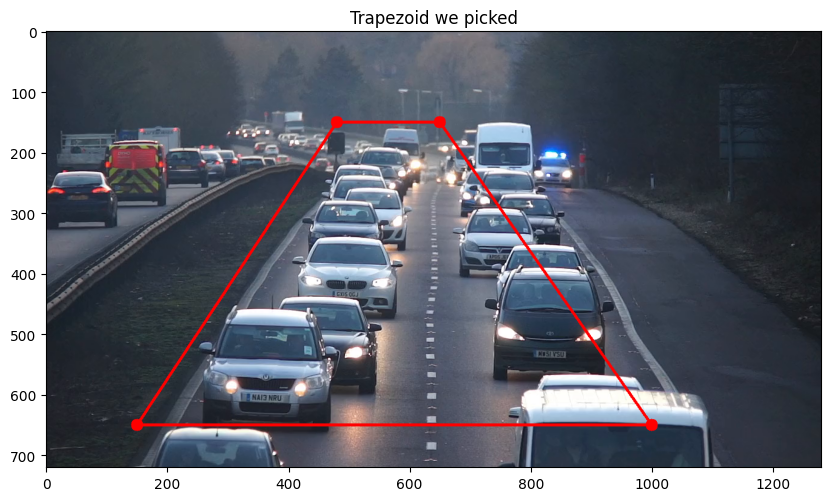

In [12]:
import numpy as np

src_points = np.float32([
    [150, 650],   # bottom-left
    [1000, 650],  # bottom-right
    [650, 150],   # top-right
    [480, 150]    # top-left
])

frame_with_points = frame_rgb.copy()
for point in src_points:
    cv2.circle(frame_with_points, (int(point[0]), int(point[1])), 10, (255, 0, 0), -1)

pts = src_points.astype(np.int32).reshape((-1, 1, 2))
cv2.polylines(frame_with_points, [pts], isClosed=True, color=(255, 0, 0), thickness=3)

plt.figure(figsize=(10,6))
plt.imshow(frame_with_points)
plt.title("Trapezoid we picked")
plt.show()

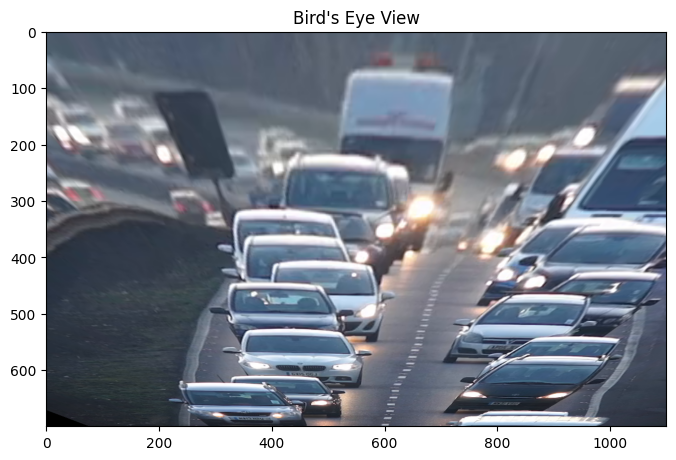

In [13]:
dst_points = np.float32([
    [200, 700],
    [900, 700],
    [900, 0],
    [200, 0]
])

matrix = cv2.getPerspectiveTransform(src_points, dst_points)

bev = cv2.warpPerspective(frame_rgb, matrix, (1100, 700))

plt.figure(figsize=(8,6))
plt.imshow(bev)
plt.title("Bird's Eye View")
plt.show()

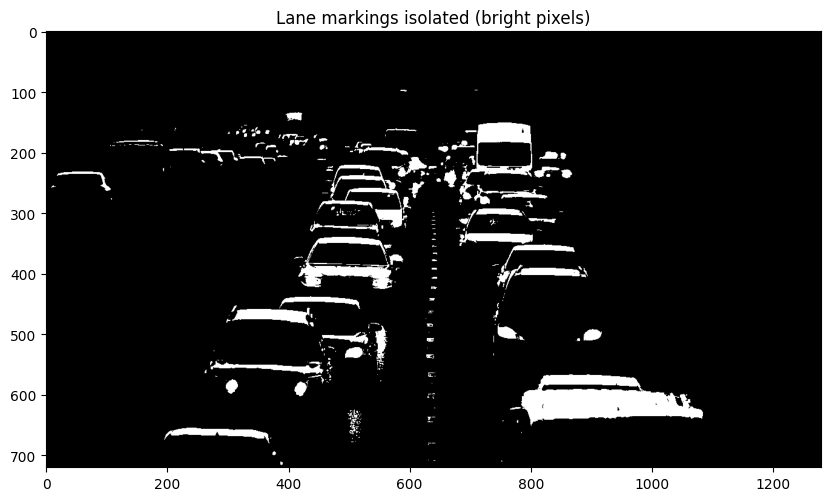

In [14]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

_, lane_mask = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(10,6))
plt.imshow(lane_mask, cmap="gray")
plt.title("Lane markings isolated (bright pixels)")
plt.show()

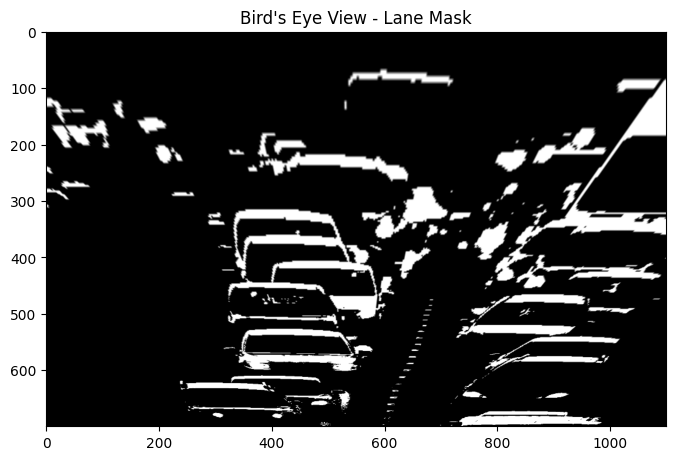

In [15]:
bev_lanes = cv2.warpPerspective(lane_mask, matrix, (1100, 700))

plt.figure(figsize=(8,6))
plt.imshow(bev_lanes, cmap="gray")
plt.title("Bird's Eye View - Lane Mask")
plt.show()